# Image Classification

tentative plan for this section:
- introduce neural networks, discuss some mathematical theory
- use neural networks for image recognition in the context of brick kilns

The main classification algorithm used for image-related tasks are deep learning-focused neural networks. Here, we will discuss neural networks on a very simplistic level; the actual architecture behind neural networks and their formation is very complex and cannot be fitted into a single section of a book.

## Neural Networks: The Basics

**Neural networks, in essence, take many different linear combinations of many features to form a new set of features. The network then takes these new features; a linear combination of them informs the final classification.**

Of course, this explanation of neural networks is highly reductionist and fails to capture almost all the details involved in its complex architecture. To better understand how neural networks work, we first need to go to their inspiration, the brain. 

### Neurons

Human brains (and the brains of many animals) are themselves a massive interconnected network of cells called *neurons*. These neurons are what relay signals between different parts of the brain, each portion of the brain handling different tasks. Neurons, at their core, have two states: resting, and excited. When resting, a neuron does not send any signals; when excited, a neuron sends a signal to another cell. Neurons can be excited through a number of different input stimuli; the neurons in your fingers are excited when you feel an object, while the neurons in your brain get excited when another neuron sends them a signal to be excited. 

The neuron of the brain formed the inspiration for the artificial neuron. Like a living neuron, an artifical neuron has two states: inactive, and active. Also like a living neuron, an artificial neuron receives a number of different inputs, but instead of sensations of chemicals, the inputs for an artificial neuron are numbers. Weights are applied to each of these inputs, and the sum of these is taken (i.e., a linear combination of these inputs). The sum then needs to be larger than a certain threshold to activate the artificial neuron. 

What does this look like, mathematically? We can display a simple example of this with two features. In the below example, the line forms a linear combination of the two features, plus an intercept (which counts as a feature that is always equal to 1).

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


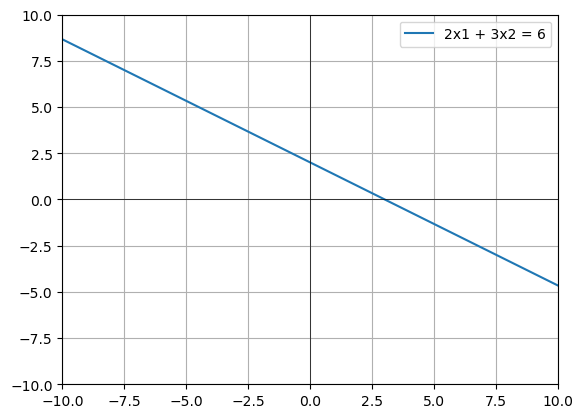

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#make a plot with x1 horizontal and x2 vertical
#and the line 2x1 + 3x2 = 6
x1 = np.linspace(-10, 10, 400)
x2 = 2 - 2/3*x1

plt.plot(x1, x2, label='2x1 + 3x2 = 6')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, which='both')
plt.legend()
plt.show()

Such a line divides this finite plane into two halves. (Even though the plane extends infinitely in theory, the line still divides it, but for practicality's sake, most features take on a finite range of values.) On one half of this plane, we have feature pairs where the linear combination of $2x_1 + 3x_2 > 6$; the other half has pairs where $2x_1 + 3x_2 < 6$. We can plot these as follows:

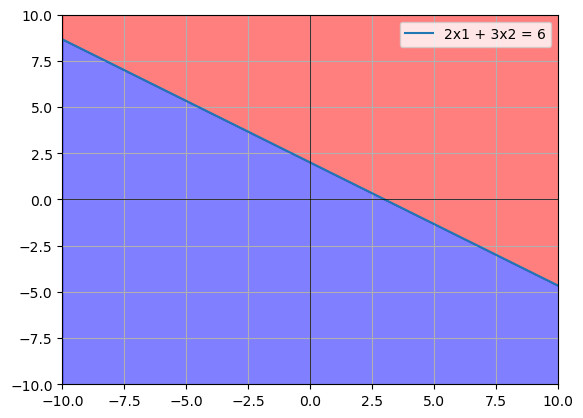

In [2]:
#same plot as above, but add shading to regions divided by the line
#for 2x1 + 3x2 > 6 in red and 2x1 + 3x2 < 6 in blue
x1 = np.linspace(-10, 10, 400)
x2 = 2 - 2/3*x1

plt.plot(x1, x2, label='2x1 + 3x2 = 6')
plt.fill_between(x1, x2, 10, color='red', alpha=0.5)
plt.fill_between(x1, x2, -10, color='blue', alpha=0.5)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, which='both')
plt.legend()
plt.show()

Now if we say that the pairs in the red region are of one class and the pairs in the blue region are of another class, we can see how the classification of a single neuron can work. It simply takes a linear combination of all the features and checks if that combination is greater than its required threshold to classify it. 

## Classification with Brick Kiln Images

In [3]:
#helper functions
#this function is taken from the KilnNet repository directly
#the batch_generator function takes in features (data x) and labels (data y) and a batch size
#not sure at the moment what is being returned but will find out later
def batch_generator(data_X, data_y, batch_size):
    indexes = np.array(range(len(data_y)))
    n = len(indexes)
    while True:
        batch_start = 0
        batch_end = batch_size
        np.random.shuffle(indexes)
        while batch_start < n:
            index = []
            batch_y = []
            y = []
            index = indexes[batch_start:batch_end]
            batch_x = np.array([data_X[i] for i in index])
            batch_y = np.array([data_y[i] for i in index])
            yield batch_x, batch_y
            batch_start += batch_size
            batch_end += batch_size
            if (batch_end>len(data_y)):
                batch_end = len(data_y)

#this function is taken from the KilnNet repository directly
#the read_landUse function takes in a dataset path and an image type
#and returns the paths to the images and the labels
#in this context, the path is the path to the folder containing the images
#and the labels are the classes of the images, like agriculutre land, forest land, etc.
def read_landUse(dataset_path, im_type):
    import glob
    paths_X = []
    labels = []
    i = 0
    folders = sorted(os.listdir(dataset_path))
    for folder in folders:
        temp = sorted (glob.glob(os.path.join(dataset_path,folder+'/*'+im_type)))
        for k in range(len(temp)):
            labels.append (i)
        paths_X += temp
        i += 1

    if(len(paths_X)==0):
        print ('Dataset could not found. Please provide correct path.')
    return paths_X, labels

In [5]:
#set directory for brick kiln data
import os
os.chdir('/Users/jonathanzhu/Documents/ev work/kilns/')

import cv2
dataset_path = 'train'
paths, labels = read_landUse(dataset_path, '[(.png)(.jpg)]')
images = np.array([cv2.imread(image_name) for image_name in paths])


In [6]:
model_name = 'VGG16_Jan2020'
num_classes = 14

from keras.utils import to_categorical
X_train = images
y_train = to_categorical(labels, num_classes)
#X, y = load_dataset(dataset_path)
print ('Size of dataset:', len(y_train))

2024-07-24 19:14:34.318420: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Size of dataset: 9227


In [7]:
dataset_path_val = 'val'
paths_val, labels_val = read_landUse(dataset_path_val, '[(.png)(.jpg)]')
X_val =  np.array([cv2.imread(image_name) for image_name in paths_val])
y_val = to_categorical(labels_val, num_classes)

In [8]:
from sklearn.model_selection import train_test_split
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2)
print(X_val.shape, X_test.shape, y_val.shape, y_test.shape)

(816, 256, 256, 3) (204, 256, 256, 3) (816, 14) (204, 14)


0 ponds 638
1 kiln 629
2 ground 1127
3 grass 630
4 houses 633
5 densetrees 635
6 farms 634
7 blackfarms 650
8 oiltanks 632
9 tennis 524
10 roads 635
11 parking 617
12 mosque 620
13 parks 623


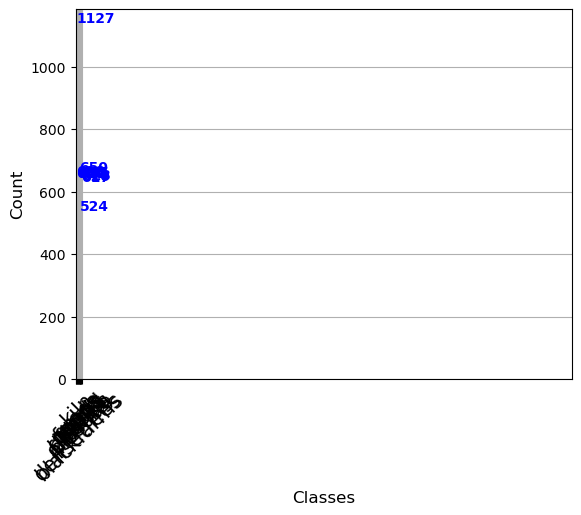

In [10]:
import pandas as pd

folders = os.listdir(dataset_path)
names, counts = [], []
for i, folder in enumerate(folders):
    dir_path = os.path.join(dataset_path, folder)
    images = os.listdir(dir_path)
    names.append(folder)
    counts.append(len(images))
    print(i, folder, len(images))
df = pd.DataFrame(data={'Name': names, 'Count': counts})
ax = df.plot(kind='bar', xticks=counts, grid=True, legend=False) #old had figsize=(16,6)
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(np.arange(len(names)), names, rotation=45, fontsize=15)
for i, v in enumerate(counts):
    ax.text(i-.18, v+15, str(v), color='blue', fontweight='bold')
plt.show()

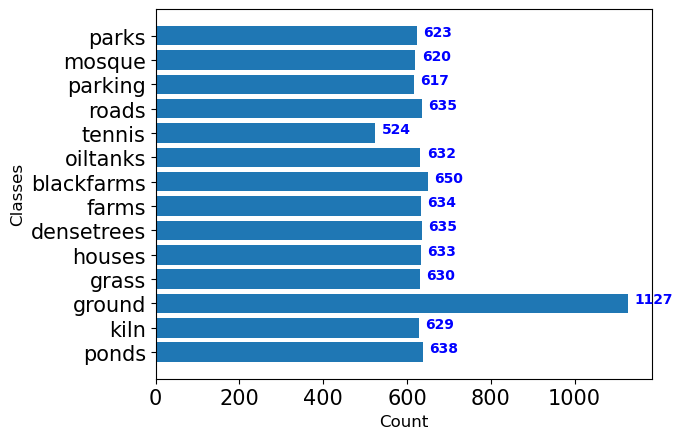

In [12]:
#can we make this plot better?
#I want to rotate the plot so that the classes are on the y-axis and the counts are on the x-axis
#also put the number next to each bar on the right side

df = pd.DataFrame(data={'Name': names, 'Count': counts})
plt.barh(df['Name'], df['Count'])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
for i, v in enumerate(counts):
    plt.text(v+15, i, str(v), color='blue', fontweight='bold')
plt.ylabel('Classes', fontsize=12)
plt.xlabel('Count', fontsize=12)    
plt.show()

In [13]:
batch_size = 10
train_gen = batch_generator(X_train, y_train, batch_size)
val_gen = batch_generator(X_val, y_val, batch_size)
#test_gen = batch_generator(X_test, y_test, batch_size)

In [15]:
#model loading and training
from keras.applications.vgg16 import VGG16
#from keras.applications.vgg19 import VGG19
#from keras.applications.resnet import ResNet50
#from keras.applications.resnet import ResNet101
#from keras.applications.resnet import ResNet152
#from keras.applications.resnet_v2 import ResNet50V2
#from keras.applications.resnet_v2 import ResNet101V2
#from keras.applications.resnet_v2 import ResNet152V2
#from keras.applications.inception_resnet_v2 import InceptionResNetV2
#from keras.applications.inception_v3 import InceptionV3
#from keras.applications.densenet import DenseNet121
#from keras.applications.densenet import DenseNet169
#from keras.applications.densenet import DenseNet201
from keras.activations import softmax, relu, sigmoid
from keras.optimizers import SGD

#uncomment to pick different models
input_shape=(256,256,3)
model= VGG16(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= VGG19(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#= ResNet101(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet152(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet101V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
# model= ResNet152V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionV3(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet121(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet169(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet201(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model =InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model = resNet(input_shape, num_classes, model_type='resnet_152')
#model.load_weights('WEIGHTS/'+model_name+'.h5')

### model_vgg16.layers[-1].activation = relu

### idx_of_layer_to_change = -1
#model.layers[idx_of_layer_to_change].activation = activations.softmax
#model = utils.apply_modifications(model)

#model_vgg16.layers[-1].activation = relu
# # FINE TUNING HERE
# top_model = Sequential()
# top_model.add(Dense(input_shape=model.layers[-2].output_shape, units=num_classes, rnel
# kernel_initializer="he_normal", activation="softmax"))

# model.layers.pop()
# model.outputs = [model.layers[-1].output]
# model.layers[-1].outbound_nodes = []

# model = Model(inputs=model.inputs, outputs=top_model(model.outputs[0]))
# # for layer in model.layers[:-1]:
# #     layer.trainable = False
#model.load_weights('WEIGHTS/'+model_name+'.h5')

model.summary()
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
# plot_model(model, to_file='model.png')

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

/opt/anaconda3/envs/nlp2/lib/python3.9/site-packages/keras/optimizers/legacy/gradient_descent.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [16]:
class_weights = {0: 629/650,
                 1: 629/635,
                 2: 629/634,
                 3: 629/630,
                 4: 629/629,
                 5: 629/633,
                 6: 629/629,
                 7: 629/620,
                 8: 629/632,
                 9: 629/617,
                 10: 629/623,
                 11:629/638,
                 12:629/635,
                 13:629/524
                }

In [17]:
import keras
from keras.callbacks import ModelCheckpoint,TensorBoard,ReduceLROnPlateau,CSVLogger, EarlyStopping
import time

checkpoint = ModelCheckpoint('WEIGHTS/'+model_name+'.h5', monitor='val_loss', verbose=2, save_best_only=True, mode='auto')
tensorboard = TensorBoard(log_dir='EVENTS/', batch_size=batch_size, write_graph=True, write_images=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=3, min_lr=0.00001)
earlystop = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=2, mode='auto')
cvslogger = keras.callbacks.CSVLogger('WEIGHTS/'+model_name+'.csv', separator=',', append=True)

#original epochs: 200
#lowered so that I can run it on my computer
nb_epoch = 200
callbacks = [checkpoint, reduce_lr, earlystop, cvslogger, tensorboard]
train_steps = int(len(y_train)//batch_size)
val_steps = int(len(y_val)//batch_size)
start_time = time.time()
history = model.fit_generator(train_gen, train_steps, epochs=nb_epoch, verbose=1,
                    max_queue_size=2, validation_data=val_gen,
                    validation_steps=val_steps, shuffle=True,
                    workers=1, use_multiprocessing= False,
                    initial_epoch=0, callbacks=callbacks, class_weight=class_weights)
print("Seconds: ", time.time() - start_time)
#model.fit(x=X[0:100], y=y[0:100], batch_size=64, epochs=2, verbose=1, callbacks=callbacks,
#          validation_split=0.2, shuffle=True,initial_epoch=0)

Epoch 1/200


/var/folders/px/b7vc3nh913zb_m0x36ncftj00000gn/T/ipykernel_40443/2977756447.py:16: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(train_gen, train_steps, epochs=nb_epoch, verbose=1,
2024-07-24 19:25:17.975717: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


922/922 [==============================] - ETA: 0s - loss: 2.6533 - accuracy: 0.1190

2024-07-24 21:00:26.046447: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Epoch 1: val_loss improved from inf to 2.63835, saving model to WEIGHTS/VGG16_Jan2020.h5
922/922 [==============================] - 5854s 6s/step - loss: 2.6533 - accuracy: 0.1190 - val_loss: 2.6384 - val_accuracy: 0.1099 - lr: 0.0100
Epoch 2/200
  6/922 [..............................] - ETA: 1:33:40 - loss: 2.6758 - accuracy: 0.1404

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import Model

model = VGG16()
# redefine model to output right after the first hidden layer
layer_output = model.get_layer('block2_conv1').output
# model = Model(inputs=model.inputs, outputs=model.layers[1].output)
model = Model(inputs=model.inputs, outputs=layer_output)
model.summary()
# load the image with the required shape
img = load_img('/content/Codes/KilnNet/Dataset/train/parks/74.5291712482_31.5705141576.png', target_size=(224, 224))
# convert the image to an array
img = img_to_array(img)
# expand dimensions so that it represents a single 'sample'
img = np.expand_dims(img, axis=0)
# prepare the image (e.g. scale pixel values for the vgg)
img = preprocess_input(img)
# get feature map for first hidden layer
feature_maps = model.predict(img)
# plot all 64 maps in an 8x8 squares
square = 11
ix = 1
for _ in range(square):
  for _ in range(square):
 # specify subplot and turn of axis
    ax = plt.subplot(square, square, ix)
    ax.set_xticks([])
    ax.set_yticks([])
 # plot filter channel in grayscale
    plt.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
    ix += 1
# show the figure
plt.show()